In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv("C:\\Users\\User\\churn-predictor\\data\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

Shape: (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
def quick_summary(df):
    return pd.DataFrame({
        "dtype":  df.dtypes,
        "nulls":  df.isnull().sum(),
        "null_%": (df.isnull().mean() * 100).round(2),
        "unique": df.nunique(),
        "sample": df.iloc[0]
    })

quick_summary(df)

,dtype,nulls,null_%,unique,sample
customerID,object,0,0.0,7043,7590-VHVEG
gender,object,0,0.0,2,Female
SeniorCitizen,int64,0,0.0,2,0
Partner,object,0,0.0,2,Yes
Dependents,object,0,0.0,2,No
tenure,int64,0,0.0,73,1
PhoneService,object,0,0.0,2,No
MultipleLines,object,0,0.0,3,No phone service
InternetService,object,0,0.0,3,DSL
OnlineSecurity,object,0,0.0,3,No


In [4]:
print(df["Churn"].value_counts())
print("\nChurn rate %:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate %:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [5]:
# Replace whitespace strings with NaN so pandas can see them
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Now convert to float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check how many were hidden
print("Missing in TotalCharges:", df["TotalCharges"].isnull().sum())

Missing in TotalCharges: 11


In [6]:
# Who are these customers with missing TotalCharges?
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [7]:
# These customers have tenure=0, meaning they just signed up
# and were never billed — safe to drop (only 11 rows out of 7043)
df = df.dropna(subset=["TotalCharges"])

print("Shape after drop:", df.shape)  # expect (7032, 21)

Shape after drop: (7032, 21)


In [8]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [9]:
df = df.drop(columns=["customerID"])

print("Final shape:", df.shape)  # expect (7032, 20)

Final shape: (7032, 20)


In [10]:
quick_summary(df)

,dtype,nulls,null_%,unique,sample
gender,object,0,0.0,2,Female
SeniorCitizen,int64,0,0.0,2,0
Partner,object,0,0.0,2,Yes
Dependents,object,0,0.0,2,No
tenure,int64,0,0.0,72,1
PhoneService,object,0,0.0,2,No
MultipleLines,object,0,0.0,3,No phone service
InternetService,object,0,0.0,3,DSL
OnlineSecurity,object,0,0.0,3,No
OnlineBackup,object,0,0.0,3,Yes


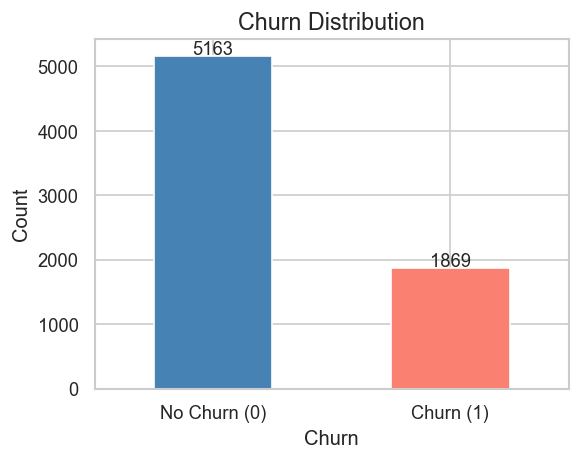

In [11]:
# Churn balance (target distribution)
fig, ax = plt.subplots(figsize=(5, 4))

df["Churn"].value_counts().plot(
    kind="bar", ax=ax,
    color=["steelblue", "salmon"],
    edgecolor="white"
)
ax.set_title("Churn Distribution", fontsize=14)
ax.set_xticklabels(["No Churn (0)", "Churn (1)"], rotation=0)
ax.set_ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height() + 30),
                ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("../data/churn_distribution.png")
plt.show()

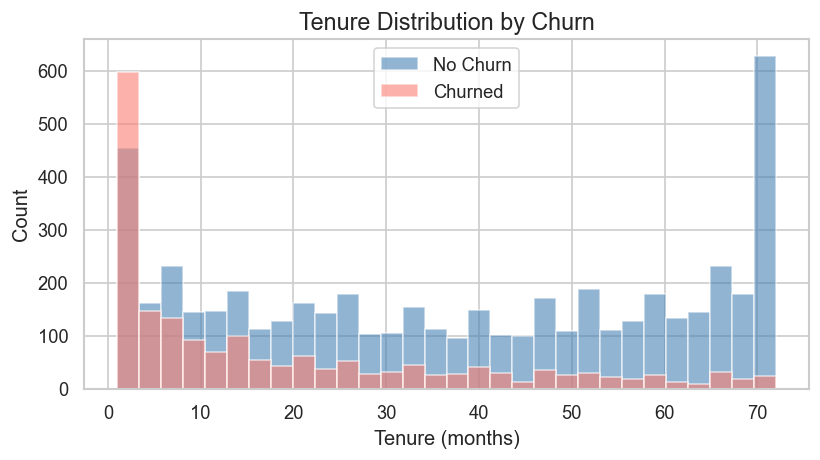

In [12]:
# Tenure vs Churn (how long before they leave?)

fig, ax = plt.subplots(figsize=(7, 4))

for churn_val, label, color in [(0, "No Churn", "steelblue"), (1, "Churned", "salmon")]:
    df[df["Churn"] == churn_val]["tenure"].plot(
        kind="hist", bins=30, alpha=0.6,
        label=label, color=color, ax=ax
    )

ax.set_title("Tenure Distribution by Churn", fontsize=14)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_22868\2890838716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_22868\2890838716.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Churn", "Churned"])


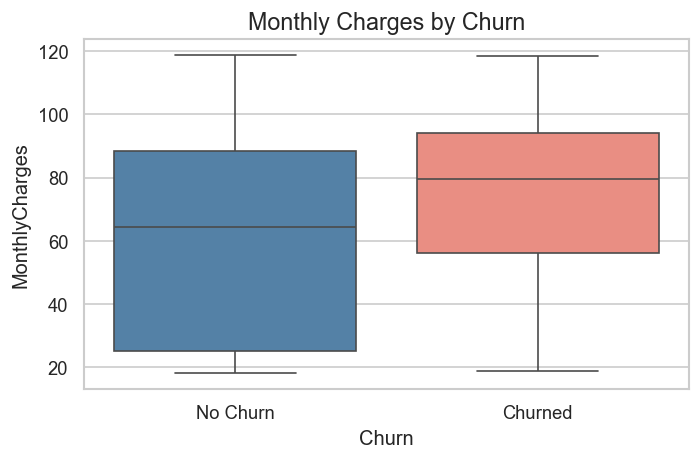

In [14]:
#  Monthly Charges vs Churn
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=df, x="Churn", y="MonthlyCharges",
    palette=["steelblue", "salmon"],
    ax=ax
)
ax.set_title("Monthly Charges by Churn", fontsize=14)
ax.set_xticklabels(["No Churn", "Churned"])
plt.tight_layout()
plt.show()

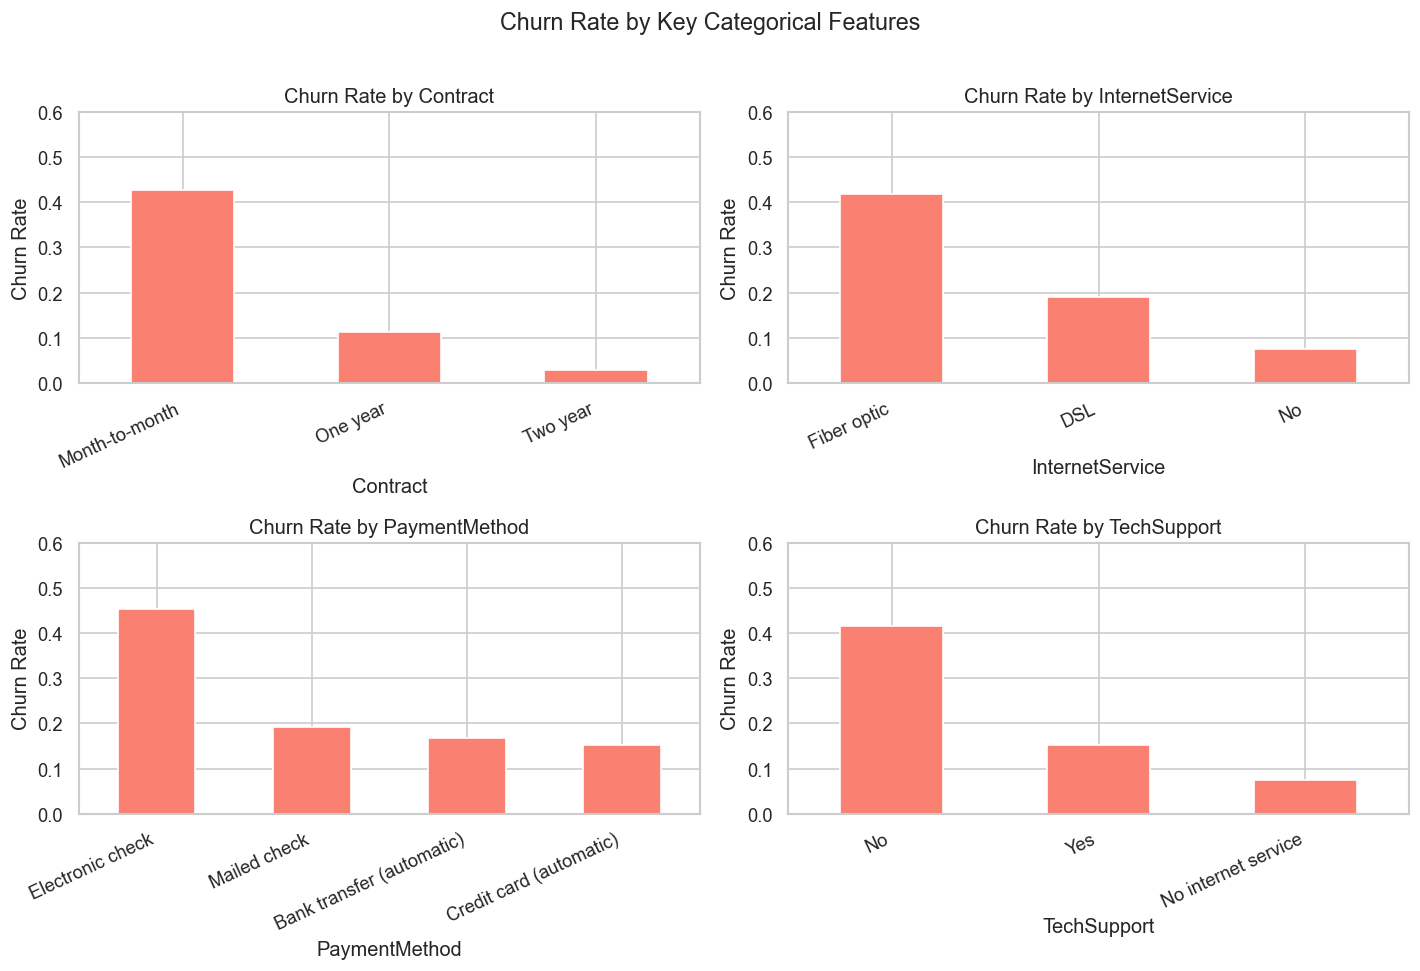

In [15]:
# Categorical features vs Churn rate
cat_cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    churn_rate.plot(kind="bar", ax=axes[i],
                    color="salmon", edgecolor="white")
    axes[i].set_title(f"Churn Rate by {col}", fontsize=12)
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=25, ha="right")
    axes[i].set_ylim(0, 0.6)

plt.suptitle("Churn Rate by Key Categorical Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# Label encode object columns just to compute correlation
df_corr = df.copy()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df_corr.select_dtypes(include="object").columns:
    df_corr[col] = le.fit_transform(df_corr[col])

df_corr.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


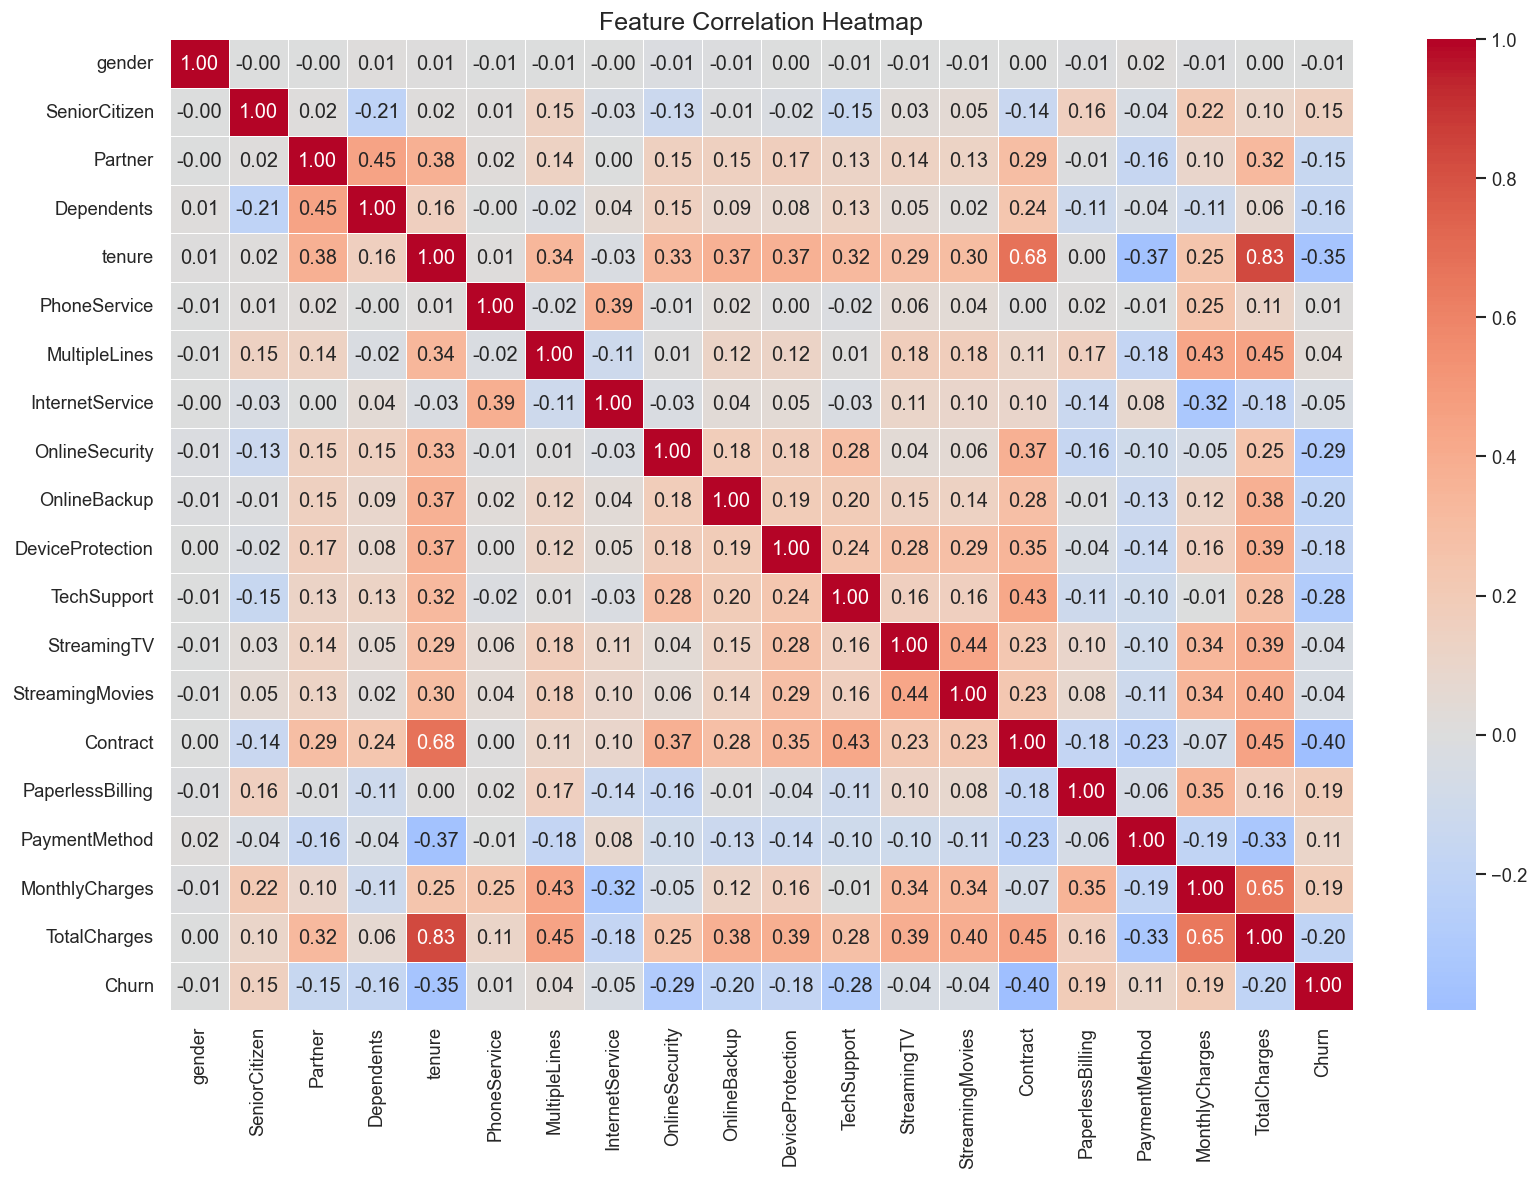

In [17]:
# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))

corr_matrix = df_corr.corr()

sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Feature Correlation Heatmap", fontsize=15)
plt.tight_layout()
plt.savefig("../data/correlation_heatmap.png")
plt.show()

In [18]:
churn_corr = df_corr.corr()["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
print("Features most correlated with Churn:\n")
print(churn_corr.round(3))

Features most correlated with Churn:

Contract           -0.396
tenure             -0.354
OnlineSecurity     -0.289
TechSupport        -0.282
TotalCharges       -0.199
OnlineBackup       -0.195
MonthlyCharges      0.193
PaperlessBilling    0.191
DeviceProtection   -0.178
Dependents         -0.163
SeniorCitizen       0.151
Partner            -0.150
PaymentMethod       0.108
InternetService    -0.047
StreamingMovies    -0.039
MultipleLines       0.038
StreamingTV        -0.036
PhoneService        0.012
gender             -0.009
Name: Churn, dtype: float64


In [19]:
df.to_csv("../data/telco_churn_clean.csv", index=False)
print("✅ Clean data saved — shape:", df.shape)

✅ Clean data saved — shape: (7032, 20)
